# Snippet - K-Neared Neighborhood
A classificação baseada em vizinhos é um tipo de aprendizagem baseada em instâncias ou aprendizagem não generalizante: ela não tenta construir um modelo interno geral, mas simplesmente armazena instâncias dos dados de treinamento.
A classificação é calculada a partir de uma votação por maioria simples dos vizinhos mais próximos de cada ponto: a um ponto de consulta é atribuída a classe de dados que tem mais representantes dentro dos vizinhos mais próximos do ponto.


<img src="./img/KNN_plot.png" alt="Plot de exemplo da área de classificação e seu respectivo NCA." style="height:300px;">
</br></br>

In [8]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import (NeighborhoodComponentsAnalysis, KNeighborsClassifier)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
# Data
X, y = load_iris(return_X_y=True)

In [3]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.7, random_state=42)

In [4]:
# Setup
nca = NeighborhoodComponentsAnalysis(random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

In [5]:
# Train
nca_pipe = Pipeline([('nca',nca),('knn',knn)])
nca_pipe.fit(X_train,y_train)

,steps,"[('nca', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,None
,init,'auto'
,warm_start,False
,max_iter,50
,tol,1e-05
,callback,None
,verbose,0


In [6]:
# Evaluate
print(nca_pipe.score(X_test,y_test))

0.9619047619047619


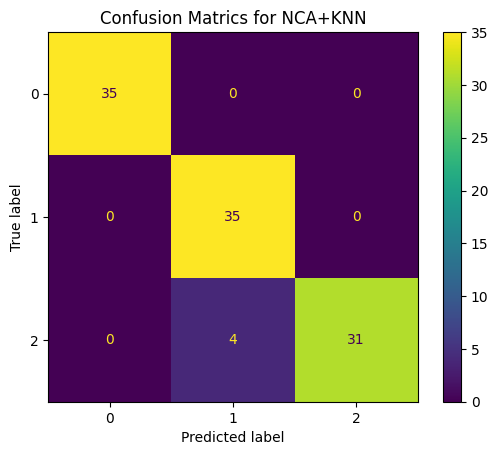

In [9]:
# Evaluate (2)
y_pred = nca_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrics for NCA+KNN")
plt.show()

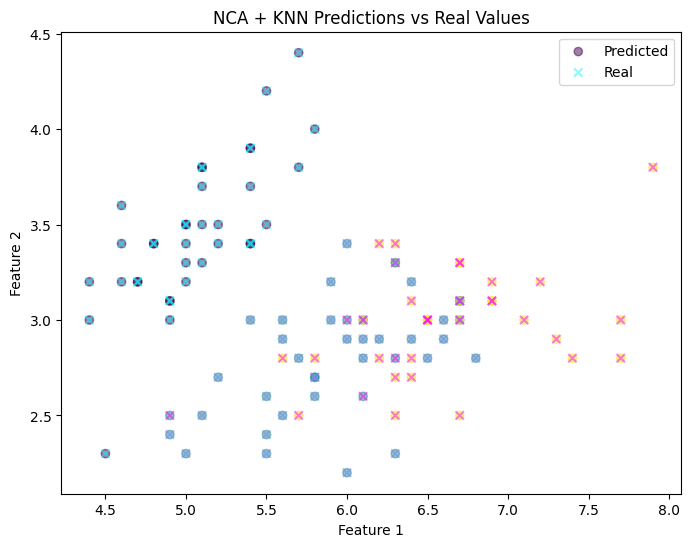

In [10]:
# Viz
plt.figure(figsize=(8,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap="viridis", marker="o", label="Predicted", alpha=0.5)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap="cool", marker="x", label="Real", alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("NCA + KNN Predictions vs Real Values")
plt.legend(["Predicted", "Real"])
plt.show()
